# Retrieval Evaluation Analysis

## 1. Objective

This notebook analyzes the performance of three chunking strategies used
in the PravAI retrieval pipeline:

- Fixed-size chunking
- Recursive chunking
- Legal-aware chunking

The objective is to determine how chunking strategy affects semantic
retrieval quality over a corpus of Serbian legislation.

The evaluation uses:

- Recall@1
- Recall@3
- Recall@5
- Mean Reciprocal Rank (MRR)

The analysis also investigates per-question performance and retrieval
failure cases in order to understand why different chunking strategies
perform differently.

## 2. Dataset Overview

In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
dataset_path = Path('../../data/evaluation/retrieval_questions.json')

with dataset_path.open('r', encoding='utf-8') as file:
    questions = json.load(file)

df_questions = pd.DataFrame(questions)
df_questions.head()

,id,question,expected_document,expected_articles
0,q001,Šta predstavlja državnu upravu i koji organi j...,Zakon_o_drzavnoj_upravi,[1]
1,q002,Ko vrši nadzor nad radom organa državne uprave?,Zakon_o_drzavnoj_upravi,[3]
2,q003,Šta je lokalna samouprava prema Zakonu o lokal...,Zakon_o_lokalnoj_samoupravi,[2]
3,q004,Koje poslove obavlja opština preko svojih organa?,Zakon_o_lokalnoj_samoupravi,[20]
4,q005,Ko ima svojstvo stranke u upravnom postupku?,Zakon_o_opstem_upravnom_postupku,[44]


In [9]:
print(f'Number of questions: {len(df_questions)}')
print(f'Number of unique documents: {df_questions['expected_document'].nunique()}')

questions_per_document = (
    df_questions['expected_document']
    .value_counts()
    .sort_index()
)
questions_per_document

Number of questions: 50
Number of unique documents: 25


expected_document
Krivicni_zakonik                                       2
Porodicni_zakon                                        2
Ustav_Republike_Srbije                                 2
Zakon_o_bezbednosti_i_zdravlju_na_radu                 2
Zakon_o_drzavnoj_upravi                                2
Zakon_o_javnim_nabavkama                               2
Zakon_o_lokalnoj_samoupravi                            2
Zakon_o_nasledjivanju                                  2
Zakon_o_obligacionim_odnosima                          2
Zakon_o_opstem_upravnom_postupku                       2
Zakon_o_osnovama_svojinskopravnih_odnosa               2
Zakon_o_poreskom_postupku_i_poreskoj_administraciji    2
Zakon_o_porezu_na_dobit_pravnih_lica                   2
Zakon_o_porezu_na_dodatu_vrednost                      2
Zakon_o_porezu_na_dohodak_gradjana                     2
Zakon_o_prekrsajima                                    2
Zakon_o_racunovodstvu                                  2
Zakon_o_regis

## 3. Load results

In [12]:
evaluation_dir = Path('../../data/evaluation')

with (evaluation_dir / 'fixed_results.json').open('r', encoding='utf-8') as file:
    fixed_results = json.load(file)

with (evaluation_dir / 'recursive_results.json').open('r', encoding='utf-8') as file:
    recursive_results = json.load(file)

with (evaluation_dir / 'legal_results.json').open('r', encoding='utf-8') as file:
    legal_results = json.load(file)

fixed_df = pd.DataFrame(fixed_results)
recursive_df = pd.DataFrame(recursive_results)
legal_df = pd.DataFrame(legal_results)

## 4. Overall metrics

In [13]:
metrics = pd.DataFrame({
    'fixed': {
        'Recall@1': sum(r['hit_at_1'] for r in fixed_results) / len(fixed_results),
        'Recall@3': sum(r['hit_at_3'] for r in fixed_results) / len(fixed_results),
        'Recall@5': sum(r['hit_at_5'] for r in fixed_results) / len(fixed_results),
        'MRR': sum(r['reciprocal_rank'] for r in fixed_results) / len(fixed_results),
    },
    'recursive': {
        'Recall@1': sum(r['hit_at_1'] for r in recursive_results) / len(recursive_results),
        'Recall@3': sum(r['hit_at_3'] for r in recursive_results) / len(recursive_results),
        'Recall@5': sum(r['hit_at_5'] for r in recursive_results) / len(recursive_results),
        'MRR': sum(r['reciprocal_rank'] for r in recursive_results) / len(recursive_results),
    },
    'legal': {
        'Recall@1': sum(r['hit_at_1'] for r in legal_results) / len(legal_results),
        'Recall@3': sum(r['hit_at_3'] for r in legal_results) / len(legal_results),
        'Recall@5': sum(r['hit_at_5'] for r in legal_results) / len(legal_results),
        'MRR': sum(r['reciprocal_rank'] for r in legal_results) / len(legal_results),
    }
}).T

metrics

,Recall@1,Recall@3,Recall@5,MRR
fixed,0.16,0.22,0.24,0.194000
recursive,0.06,0.14,0.16,0.094000
legal,0.20,0.36,0.38,0.270667


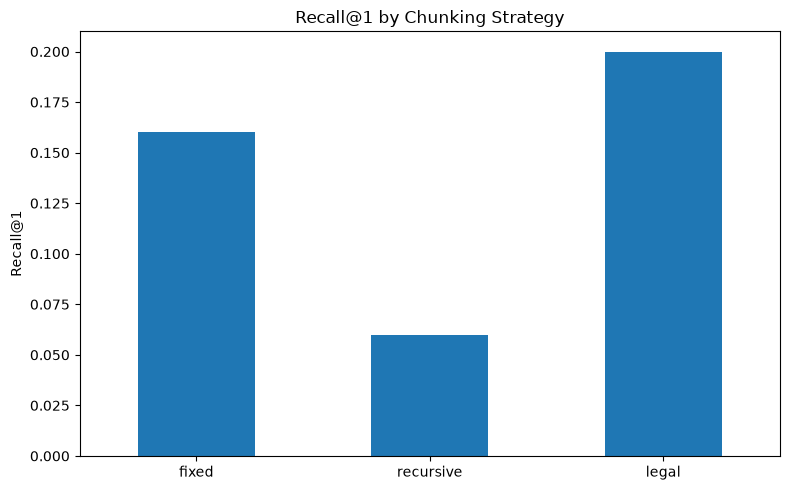

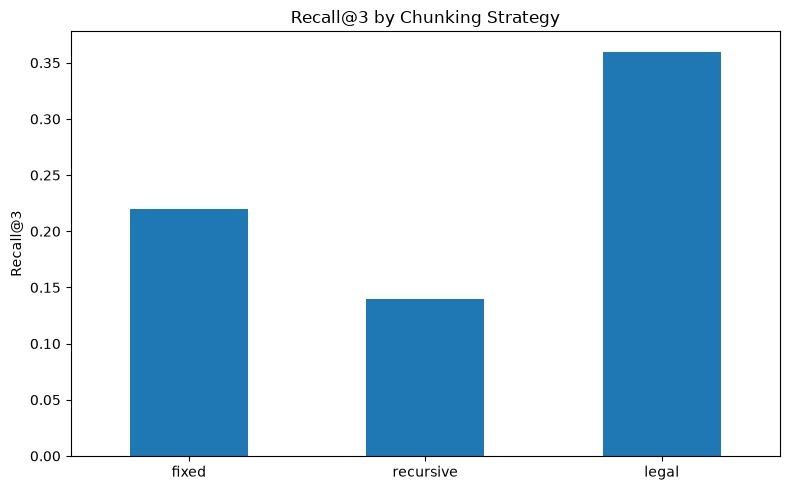

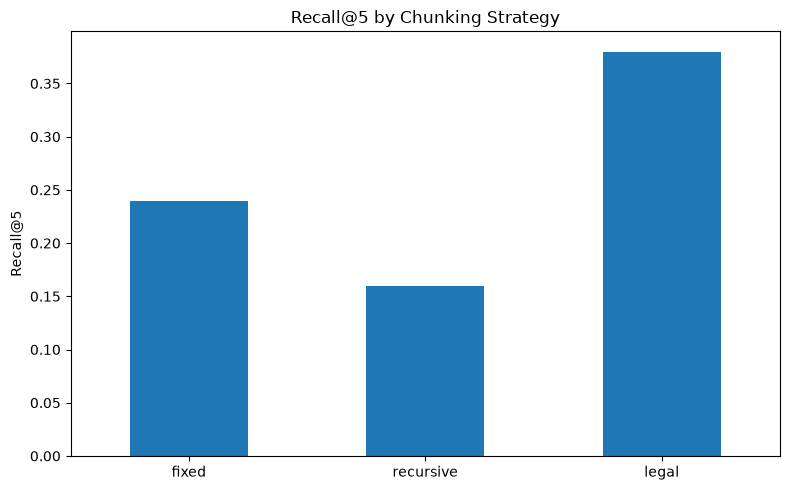

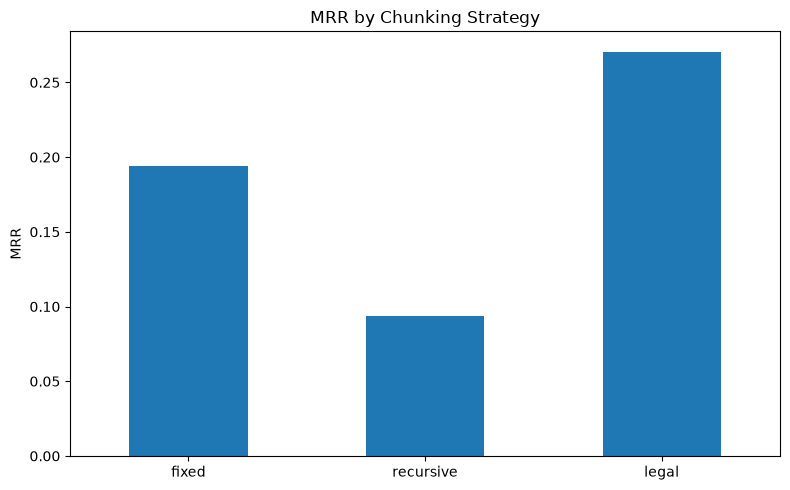

In [14]:
for metric in ['Recall@1', 'Recall@3', 'Recall@5', 'MRR']:
    plt.figure(figsize=(8, 5))

    metrics[metric].plot(kind='bar')

    plt.ylabel(metric)
    plt.title(f'{metric} by Chunking Strategy')
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [15]:
comparison = pd.DataFrame(index=metrics.index)

comparison['Recall@1'] = metrics['Recall@1']
comparison['Recall@3'] = metrics['Recall@3']
comparison['Recall@5'] = metrics['Recall@5']
comparison['MRR'] = metrics['MRR']

comparison

,Recall@1,Recall@3,Recall@5,MRR
fixed,0.16,0.22,0.24,0.194000
recursive,0.06,0.14,0.16,0.094000
legal,0.20,0.36,0.38,0.270667


In [16]:
for metric in metrics.columns:
    fixed_value = metrics.loc['fixed', metric]
    legal_value = metrics.loc['legal', metric]

    improvement = (legal_value - fixed_value) / fixed_value * 100

    print(f'{metric}: {improvement:.2f}% improvement')

Recall@1: 25.00% improvement
Recall@3: 63.64% improvement
Recall@5: 58.33% improvement
MRR: 39.52% improvement


## 5. Performance by rank

In [17]:
def rank_distribution(results):
    ranks = []

    for result in results:
        rank = result['first_relevant_rank']

        if rank is None:
            ranks.append('Not retrieved')
        else:
            ranks.append(f'Rank {rank}')

    return pd.Series(ranks).value_counts()

In [18]:
for strategy, results in {
    'Fixed': fixed_results,
    'Recursive': recursive_results,
    'Legal': legal_results,
}.items():

    print(strategy)
    print(rank_distribution(results))
    print()

Fixed
Not retrieved    38
Rank 1            8
Rank 2            3
Rank 5            1
Name: count, dtype: int64

Recursive
Not retrieved    42
Rank 3            3
Rank 1            3
Rank 5            1
Rank 2            1
Name: count, dtype: int64

Legal
Not retrieved    31
Rank 1           10
Rank 3            4
Rank 2            4
Rank 5            1
Name: count, dtype: int64



## 6. Per-question analysis

In [19]:
def create_rank_map(results):
    return {
        result['question_id']: result['first_relevant_rank']
        for result in results
    }

fixed_ranks = create_rank_map(fixed_results)
recursive_ranks = create_rank_map(recursive_results)
legal_ranks = create_rank_map(legal_results)

question_analysis = df_questions[
    ['id', 'question', 'expected_document', 'expected_articles']
].copy()

question_analysis['fixed_rank'] = question_analysis['id'].map(fixed_ranks)
question_analysis["recursive_rank"] = question_analysis["id"].map(recursive_ranks)
question_analysis["legal_rank"] = question_analysis["id"].map(legal_ranks)

question_analysis

,id,question,expected_document,expected_articles,fixed_rank,recursive_rank,legal_rank
0,q001,Šta predstavlja državnu upravu i koji organi j...,Zakon_o_drzavnoj_upravi,[1],NaN,NaN,NaN
1,q002,Ko vrši nadzor nad radom organa državne uprave?,Zakon_o_drzavnoj_upravi,[3],NaN,NaN,1.0
2,q003,Šta je lokalna samouprava prema Zakonu o lokal...,Zakon_o_lokalnoj_samoupravi,[2],NaN,3.0,NaN
3,q004,Koje poslove obavlja opština preko svojih organa?,Zakon_o_lokalnoj_samoupravi,[20],NaN,NaN,NaN
4,q005,Ko ima svojstvo stranke u upravnom postupku?,Zakon_o_opstem_upravnom_postupku,[44],NaN,NaN,NaN
5,q006,U kom roku se podnosi žalba protiv rešenja u u...,Zakon_o_opstem_upravnom_postupku,[153],NaN,NaN,NaN
6,q007,Ko može da pokrene upravni spor?,Zakon_o_upravnim_sporovima,[11],NaN,NaN,NaN
7,q008,Da li tužba u upravnom sporu po pravilu odlaže...,Zakon_o_upravnim_sporovima,[23],2.0,NaN,3.0
8,q011,Šta se smatra diskriminacijom prema Zakonu o z...,Zakon_o_zabrani_diskriminacije,[2],1.0,1.0,NaN
9,q012,Da li je diskriminacija zabranjena u oblasti r...,Zakon_o_zabrani_diskriminacije,[16],1.0,5.0,1.0


## 7. Strategy win/loss analysis

In [20]:
def get_hit_map(results):
    return {
        result['question_id']: result['hit_at_5']
        for result in results
    }

fixed_hits = get_hit_map(fixed_results)
recursive_hits = get_hit_map(recursive_results)
legal_hits = get_hit_map(legal_results)

In [21]:
question_analysis['fixed_hit'] = question_analysis['id'].map(fixed_hits)
question_analysis['recursive_hit'] = question_analysis['id'].map(recursive_hits)
question_analysis['legal_hit'] = question_analysis['id'].map(legal_hits)

In [24]:
def classify_result(row):
    fixed = row['fixed_hit']
    recursive = row['recursive_hit']
    legal = row['legal_hit']

    if legal and not fixed and not recursive:
        return 'Legal only'

    if fixed and not legal and not recursive:
        return 'Fixed only'

    if recursive and not legal and not fixed:
        return 'Recursive only'

    if legal and fixed and recursive:
        return 'All strategies'

    if legal and fixed:
        return 'Legal + Fixed'

    if legal and recursive:
        return 'Legal + Recursive'

    if fixed and recursive:
        return 'Fixed + Recursive'

    return 'None'

question_analysis['category'] = (
    question_analysis.apply(
        classify_result,
        axis=1
    )
)

question_analysis['category'].value_counts()

category
None                 25
Legal only           12
Legal + Fixed         4
Fixed + Recursive     4
All strategies        3
Recursive only        1
Fixed only            1
Name: count, dtype: int64

## 8. Failure analysis

In [25]:
all_failed = question_analysis[
    ~question_analysis['fixed_hit']
    & ~question_analysis['recursive_hit']
    & ~question_analysis['legal_hit']
]

all_failed[
    [
        'id',
        'question',
        'expected_document',
        'expected_articles',
    ]
]

,id,question,expected_document,expected_articles
0,q001,Šta predstavlja državnu upravu i koji organi j...,Zakon_o_drzavnoj_upravi,[1]
3,q004,Koje poslove obavlja opština preko svojih organa?,Zakon_o_lokalnoj_samoupravi,[20]
4,q005,Ko ima svojstvo stranke u upravnom postupku?,Zakon_o_opstem_upravnom_postupku,[44]
5,q006,U kom roku se podnosi žalba protiv rešenja u u...,Zakon_o_opstem_upravnom_postupku,[153]
6,q007,Ko može da pokrene upravni spor?,Zakon_o_upravnim_sporovima,[11]
10,q013,Koje su osnovne obaveze poslodavca u oblasti b...,Zakon_o_bezbednosti_i_zdravlju_na_radu,[15]
11,q014,Kada je poslodavac dužan da obezbedi izdavanje...,Zakon_o_bezbednosti_i_zdravlju_na_radu,[27]
14,q017,Na koji način se stiče pravo svojine?,Zakon_o_osnovama_svojinskopravnih_odnosa,[20]
18,q021,Na osnovu kojih pravnih osnova se može naslediti?,Zakon_o_nasledjivanju,[2]
19,q022,Ko čini prvi nasledni red?,Zakon_o_nasledjivanju,[9]


## 9. Similarity analysis

In [26]:
def first_result_similarity(results):
    return pd.DataFrame({
        'question_id': [r['question_id'] for r in results],
        'similarity': [
            r['results'][0]['similarity']
            for r in results
        ],
        'first_relevant_rank': [
            r['first_relevant_rank']
            for r in results
        ],
    })

In [27]:
legal_similarity = first_result_similarity(legal_results)
legal_similarity.describe()

,similarity,first_relevant_rank
count,50.000000,19.000000
mean,0.746087,1.842105
std,0.085056,1.118688
min,0.514504,1.000000
25%,0.711766,1.000000
50%,0.770057,1.000000
75%,0.805121,2.500000
max,0.872877,5.000000


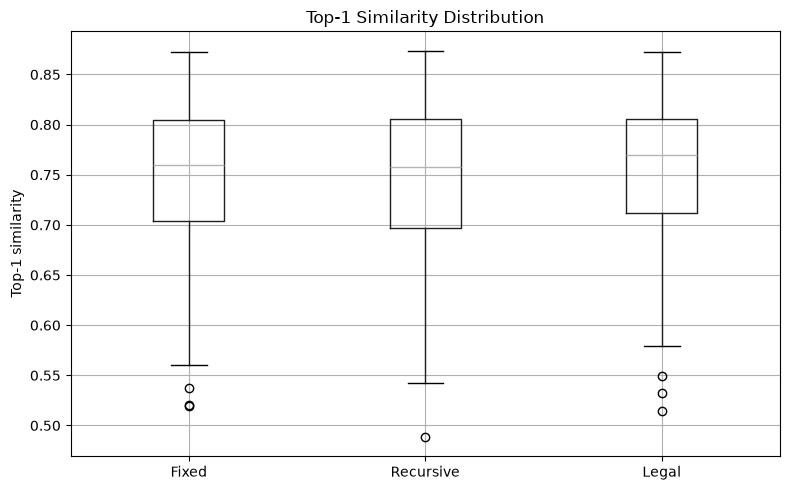

In [28]:
similarity_data = pd.DataFrame({
    'Fixed': first_result_similarity(fixed_results)['similarity'],
    'Recursive': first_result_similarity(recursive_results)['similarity'],
    'Legal': first_result_similarity(legal_results)['similarity'],
})

similarity_data.boxplot(figsize=(8, 5))

plt.ylabel('Top-1 similarity')
plt.title('Top-1 Similarity Distribution')

plt.tight_layout()
plt.show()

A high semantic similarity score does not necessarily mean that the
retrieved chunk contains the expected legal article.

This distinction is important in legal retrieval because semantically
related provisions may belong to different laws or regulate related but
different legal concepts.

Therefore, similarity scores are analyzed separately from ground-truth
retrieval metrics.

## 10. Conclusions

The retrieval experiment compares fixed-size, recursive, and legal-aware
chunking strategies over Serbian legal documents.

The results indicate that chunking strategy has a substantial effect on
retrieval quality.

Legal-aware chunking achieved:

- Recall@1: 0.20
- Recall@3: 0.36
- Recall@5: 0.38
- MRR: 0.2707

Fixed-size chunking achieved:

- Recall@1: 0.16
- Recall@3: 0.22
- Recall@5: 0.24
- MRR: 0.1940

Recursive chunking achieved:

- Recall@1: 0.06
- Recall@3: 0.14
- Recall@5: 0.16
- MRR: 0.0940

The analysis should be interpreted as a retrieval baseline rather than
evidence that one strategy is universally superior. In particular,
per-question and failure analysis are necessary to understand cases where
different strategies retrieve different legal provisions.

The observed results provide a baseline for the next stage of the project:
improving retrieval through reranking and comparing the improved system
against these baseline strategies.